📖 Caricamento Master Dataset...

📊 REPORT LGTM SMELL - SOLO PR MERGED
Soglia complessità: > 25 righe modificate
AGENTE          | APPROVAZIONI | LGTM SMELLS  | INCIDENZA (%)
-------------------------------------------------------------
OpenAI_Codex    | 397          | 238          |        59.95%
Cursor          | 148          | 83           |        56.08%
Devin           | 685          | 260          |        37.96%
Human           | 1283         | 460          |        35.85%
Claude_Code     | 43           | 12           |        27.91%
Copilot         | 944          | 129          |        13.67%
-------------------------------------------------------------
💡 Media AI Agents: 39.11% | Benchmark Human: 35.85%
👉 Gli agenti AI subiscono il 3.26% in PIÙ di approvazioni 'alla cieca' rispetto agli umani.



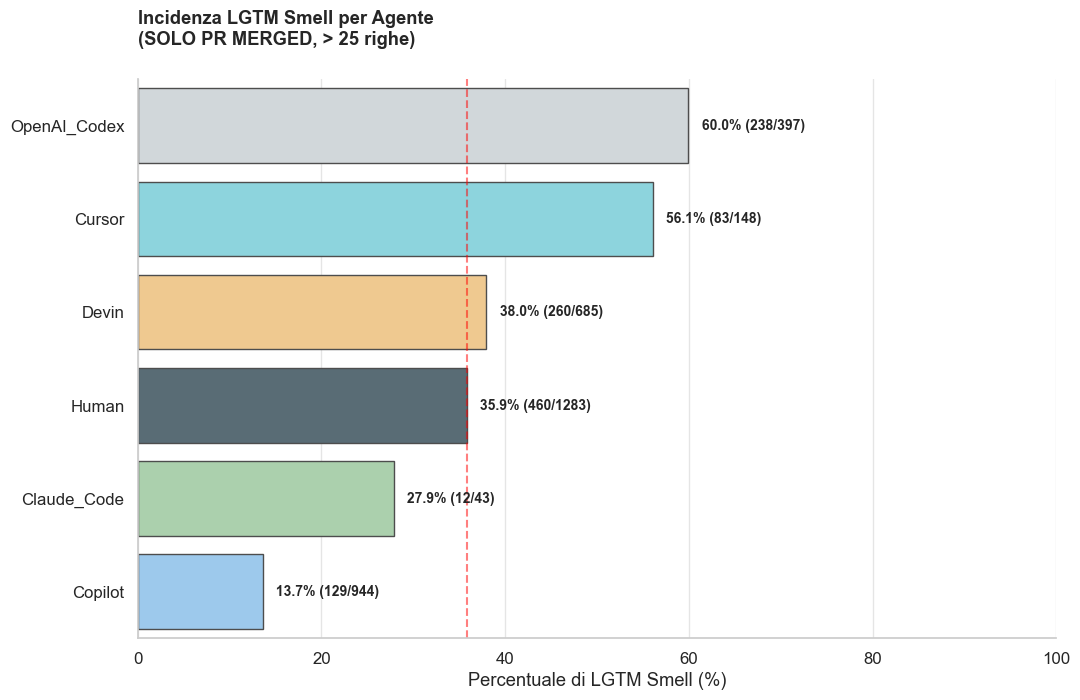

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- CONFIGURAZIONE ---
MASTER_FINAL_PATH = "dataset/all_pr_type.csv"
FIGS_DIR = Path("../figs")
ONLY_MERGED_PR = True

COLOR_MAP = {
    'Human': '#546e7a',
    'Copilot': '#90caf9', 'Claude_Code': '#a5d6a7',
    'Cursor': '#80deea', 'Devin': '#ffcc80', 'OpenAI_Codex': '#cfd8dc'
}
DEFAULT_COLOR = '#eeeeee'

def setup_style():
    sns.set_theme(style="whitegrid", font_scale=1.1)
    plt.rcParams.update({
        "axes.spines.right": False,
        "axes.spines.top": False,
        "figure.titlesize": 16
    })

def main():
    FIGS_DIR.mkdir(parents=True, exist_ok=True)
    setup_style()

    print("📖 Caricamento Master Dataset...")
    df = pd.read_csv(MASTER_FINAL_PATH)

    # Filtri di qualità (Academic Complexity Threshold)
    categories_to_exclude = ['docs', 'style', 'chore', 'ci', 'build']
    df = df[~df['type'].isin(categories_to_exclude)].copy()

    # Soglia di complessità (es. 25 righe)
    line_threshold = 25
    df = df[(df['additions'] + df['deletions'] > line_threshold)]

    if ONLY_MERGED_PR:
        df = df[df['merged_at'].notna()]
        context_label = "SOLO PR MERGED"
    else:
        context_label = "TUTTE LE PR"

    # 1. Calcolo LGTM Smell
    df['is_lgtm_smell'] = (
        (df['has_approved_review'] == True) &
        (df['n_general_comments'] == 0) &
        (df['n_inline_comments'] == 0) &
        (df['has_interaction_review'] == False)
    )

    # 2. Aggregazione
    stats = df[df['has_approved_review'] == True].groupby('agent').agg(
        totale_approvazioni=('id', 'count'),
        lgtm_smells=('is_lgtm_smell', 'sum')
    ).reset_index()

    stats['incidenza_percentuale'] = (stats['lgtm_smells'] / stats['totale_approvazioni'] * 100).round(2)
    stats = stats.sort_values(by='incidenza_percentuale', ascending=False)

    # --- 3. STAMPA DEI RISULTATI A VIDEO ---
    print("\n" + "="*75)
    print(f"📊 REPORT LGTM SMELL - {context_label}")
    print(f"Soglia complessità: > {line_threshold} righe modificate")
    print("="*75)

    header = f"{'AGENTE':<15} | {'APPROVAZIONI':<12} | {'LGTM SMELLS':<12} | {'INCIDENZA (%)'}"
    print(header)
    print("-" * len(header))

    for _, row in stats.iterrows():
        print(f"{row['agent']:<15} | {int(row['totale_approvazioni']):<12} | "
              f"{int(row['lgtm_smells']):<12} | {row['incidenza_percentuale']:>12}%")

    print("-" * len(header))

    # Insight Comparativo
    if 'Human' in stats['agent'].values:
        h_val = stats.loc[stats['agent'] == 'Human', 'incidenza_percentuale'].values[0]
        ai_only = stats[stats['agent'] != 'Human']
        if not ai_only.empty:
            avg_ai = ai_only['incidenza_percentuale'].mean()
            diff = h_val - avg_ai
            print(f"💡 Media AI Agents: {avg_ai:.2f}% | Benchmark Human: {h_val}%")
            if diff > 0:
                print(f"👉 Gli umani ricevono il {diff:.2f}% in PIÙ di approvazioni 'alla cieca' rispetto alle AI.")
            else:
                print(f"👉 Gli agenti AI subiscono il {abs(diff):.2f}% in PIÙ di approvazioni 'alla cieca' rispetto agli umani.")
    print("="*75 + "\n")

    # --- 4. VISUALIZZAZIONE ---
    plt.figure(figsize=(11, 0.7 * len(stats) + 3))
    palette = [COLOR_MAP.get(agent, DEFAULT_COLOR) for agent in stats['agent']]

    ax = sns.barplot(
        data=stats, x='incidenza_percentuale', y='agent',
        palette=palette, hue='agent', legend=False,
        edgecolor=".3", linewidth=1
    )

    for i, p in enumerate(ax.patches):
        row = stats.iloc[i]
        val = p.get_width()
        ax.text(
            val + 1, p.get_y() + p.get_height()/2,
            f" {val:.1f}% ({int(row['lgtm_smells'])}/{int(row['totale_approvazioni'])})",
            va='center', fontweight='bold', size=10
        )

    if 'Human' in stats['agent'].values:
        plt.axvline(h_val, color='red', linestyle='--', alpha=0.5, label='Human Baseline')

    plt.title(f'Incidenza LGTM Smell per Agente\n({context_label}, > {line_threshold} righe)', loc='left', pad=25, fontweight='bold')
    plt.xlabel('Percentuale di LGTM Smell (%)')
    plt.ylabel('')
    plt.xlim(0, max(stats['incidenza_percentuale'].max() + 20, 100))
    plt.tight_layout()

    suffix = "merged" if ONLY_MERGED_PR else "all"
    plt.savefig(FIGS_DIR / f"lgtm_smell_analysis_{suffix}.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    main()

In [58]:
import pandas as pd
import re

# Caricamento
df_v1 = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_review_comments.parquet")
df_v2 = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_comments.parquet")

def analyze_and_unmask_bots(df, dataset_name="Dataset"):
    # Lista keywords e regex (la tua versione ottimizzata)
    bot_keywords = [
        r'sonar', r'codacy', r'codecov', r'coveralls', r'linter', r'snyk',
        r'whitesource', r'jenkins', r'travis', r'circleci', r'appveyor',
        r'github-actions', r'vercel', r'netlify', r'houndci',
        r'mend-bolt', r'mend-bot', r'robot', r'commenter', r'mergebot'
    ]
    safe_bot_regex = r'(-bot|_bot|\.bot|bot$|^bot-)'
    full_pattern = '|'.join(bot_keywords) + '|' + safe_bot_regex

    # Identificazione degli Shadow Bots
    mask_shadow = (df['user_type'].str.lower() == 'user') & \
                  (df['user'].str.lower().str.contains(full_pattern, na=False, regex=True))

    # Escludiamo i famosi falsi positivi (Mendoza, Garcia, etc.) se presenti
    whitelist = ['cmendible', 'francinelucca', 'arturcic', 'jasonmendoza', 'cirospaciari', 'bruno-garcia']
    mask_shadow = mask_shadow & (~df['user'].str.lower().isin(whitelist))

    shadow_bots_df = df[mask_shadow]
    unique_bots = shadow_bots_df['user'].unique()
    total_comments = len(shadow_bots_df)

    print(f"\n📊 REPORT ANALISI: {dataset_name}")
    print(f"======================================")
    print(f"👤 Shadow Bots (User) unici: {len(unique_bots)}")
    print(f"💬 Totale commenti bot rimossi: {total_comments}")
    print(f"📈 Impatto: {total_comments / len(df) * 100:.2f}% del dataset totale")
    if len(unique_bots) > 0:
        print(f"🤖 Primi nomi: {unique_bots[:10]}")

    return unique_bots

# Esecuzione sui due dataset
bot_list_v1 = analyze_and_unmask_bots(df_v1, "Review Comments (v1)")
bot_list_v2 = analyze_and_unmask_bots(df_v2, "General Comments (v2)")


📊 REPORT ANALISI: Review Comments (v1)
👤 Shadow Bots (User) unici: 2
💬 Totale commenti bot rimossi: 6
📈 Impatto: 0.03% del dataset totale
🤖 Primi nomi: ['houndci-bot' 'eliatcodecov']

📊 REPORT ANALISI: General Comments (v2)
👤 Shadow Bots (User) unici: 31
💬 Totale commenti bot rimossi: 354
📈 Impatto: 0.90% del dataset totale
🤖 Primi nomi: ['pytorchmergebot' 'pyvista-bot' 'coveralls' 'mm-cloud-bot'
 'RevenueCat-Danger-Bot' 'facebook-github-bot' 'codecov-commenter'
 'sre-ci-robot' 'k8s-ci-robot' 'k8s-infra-cherrypick-robot']


C:\Users\Samuele\AppData\Local\Temp\ipykernel_8548\149960620.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df['user'].str.lower().str.contains(full_pattern, na=False, regex=True))


In [61]:
import pandas as pd
import re

def verify_keyword_utility(df, keywords):
    stats = []

    # Pulizia preliminare: solo utenti di tipo 'User'
    df_users = df[df['user_type'].str.lower() == 'user'].copy()

    for kw in keywords:
        # Contiamo i match per questa specifica keyword
        matches = df_users[df_users['user'].str.lower().str.contains(kw, na=False, regex=True)]
        unique_users = matches['user'].unique()
        count_comments = len(matches)

        stats.append({
            'Keyword': kw,
            'Bots_Trovati': len(unique_users),
            'Commenti_Rimossi': count_comments,
            'Esempi_Nomi': list(unique_users[:3]) # Giusto per vedere chi ha preso
        })

    # Creiamo un report ordinato per utilità
    report_df = pd.DataFrame(stats).sort_values(by='Commenti_Rimossi', ascending=False)
    return report_df

# Utilizzo
bot_keywords = [
    r'sonar', r'codacy', r'codecov', r'coveralls', r'linter', r'snyk',
    r'whitesource', r'jenkins', r'travis', r'circleci', r'appveyor',
    r'github-actions', r'vercel', r'netlify', r'houndci',
    r'mend-bolt', r'mend-bot', r'robot', r'commenter', r'mergebot'
]

# Esegui sui tuoi dataset
report_v1 = verify_keyword_utility(df_v1, bot_keywords)
report_v2 = verify_keyword_utility(df_v2, bot_keywords)
print("📊 UTILITÀ KEYWORDS (Review Comments):")
print(report_v1[['Keyword', 'Bots_Trovati', 'Commenti_Rimossi']])
print(report_v2[['Keyword', 'Bots_Trovati', 'Commenti_Rimossi']])

📊 UTILITÀ KEYWORDS (Review Comments):
           Keyword  Bots_Trovati  Commenti_Rimossi
14         houndci             1                 5
2          codecov             1                 1
1           codacy             0                 0
0            sonar             0                 0
3        coveralls             0                 0
4           linter             0                 0
6      whitesource             0                 0
5             snyk             0                 0
8           travis             0                 0
9         circleci             0                 0
10        appveyor             0                 0
7          jenkins             0                 0
11  github-actions             0                 0
12          vercel             0                 0
13         netlify             0                 0
15       mend-bolt             0                 0
16        mend-bot             0                 0
17           robot             0            